# 06 — Extra Experiments

Two additional analyses beyond notebook 04:

1. **Non-projectivity slice.** Split arcs into projective vs non-projective (gold-tree) and measure UAS/LAS separately. Direct test of the theoretical claim that graph-based parsers beat transition-based on non-projective constructions.
2. **EN label-fairness check.** spaCy's `en_core_web_trf` emits CLEAR-style labels, depressing raw LAS. Apply a CLEAR→UD remap (`src/label_map.py`) and recompute LAS — answers whether the EN LAS gap is driven by labels or by attachment.

**Run after** notebooks 02–04 (this notebook re-parses — no shared cache).


In [1]:
# === Kaggle / Colab setup (skip if running locally) ===
import os, subprocess, sys
from pathlib import Path

IS_KAGGLE = Path("/kaggle/working").exists()
IS_COLAB  = "google.colab" in sys.modules

if IS_KAGGLE or IS_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-r", "../requirements.txt"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "--force-reinstall", "--no-deps",
                    "numpy<2", "pandas>=2.0,<2.3"], check=True)
    subprocess.run([sys.executable, "-m", "spacy", "download",
                    "en_core_web_trf"], check=True)
    subprocess.run([sys.executable, "-m", "spacy", "download",
                    "ru_core_news_lg"], check=True)
    subprocess.run([sys.executable, "../scripts/download_data.py"],
                   check=True)
    print("Setup done.")
else:
    print("Local env detected — skipping cloud setup.")

Local env detected — skipping cloud setup.


In [2]:
import sys
sys.path.insert(0, "..")

from pathlib import Path
import pandas as pd
from tqdm import tqdm

from src.data import load_sentences
from src.parsers import SpacyParser, StanzaParser
from src.metrics import Gold, Prediction, _is_punct
from src.projectivity import nonprojective_arc_mask
from src.label_map import remap_label

SENTS = {
    "en": load_sentences(Path("../data/en_ewt_test.conllu")),
    "ru": load_sentences(Path("../data/ru_syntagrus_test.conllu")),
}
PARSERS = {
    "en": [SpacyParser("en_core_web_trf"), StanzaParser("en")],
    "ru": [SpacyParser("ru_core_news_lg"), StanzaParser("ru")],
}
print(f"EN: {len(SENTS['en'])} sents | RU: {len(SENTS['ru'])} sents")

EN: 2077 sents | RU: 8800 sents


In [3]:
# Re-parse (same pattern as notebook 04)
CHUNK = 100
PARSES = {}
for lang, sents in SENTS.items():
    toks_all = [s.tokens for s in sents]
    for parser in PARSERS[lang]:
        results = []
        for i in tqdm(range(0, len(toks_all), CHUNK), desc=f"{lang}-{parser.name}"):
            results.extend(parser.parse(toks_all[i:i+CHUNK]))
        PARSES[(lang, parser.name)] = [Prediction(r.heads, r.deprels) for r in results]
print("Done parsing.")

en-spacy:en_core_web_trf:   0%|          | 0/21 [00:00<?, ?it/s]/Users/aleksandrgavkovskij/programming/nlp_case_study/.venv/lib/python3.12/site-packages/thinc/shims/pytorch.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self._mixed_precision):
ru-stanza:ru: 100%|██████████| 88/88 [02:29<00:00,  1.69s/it]

Done parsing.


## 1. Non-projectivity slice

Classify each gold arc as projective or non-projective using `nonprojective_arc_mask` on the **gold** heads. Measure UAS/LAS on each slice for each parser.

In [4]:
# Count non-projective rates in each treebank
for lang, sents in SENTS.items():
    total = np_arcs = np_sents = 0
    for s in sents:
        mask = nonprojective_arc_mask(s.heads)
        n_np = sum(mask)
        total += sum(1 for d in s.deprels if not _is_punct(d))
        np_arcs += n_np
        if n_np > 0:
            np_sents += 1
    print(f"{lang}: {np_arcs}/{total} non-projective arcs ({np_arcs/total:.2%}); "
          f"{np_sents}/{len(sents)} sentences contain ≥1 NP arc ({np_sents/len(sents):.2%})")

en: 49/22029 non-projective arcs (0.22%); 31/2077 sentences contain ≥1 NP arc (1.49%)
ru: 1357/128255 non-projective arcs (1.06%); 593/8800 sentences contain ≥1 NP arc (6.74%)


In [5]:
rows = []
for (lang, pname), preds in PARSES.items():
    sents = SENTS[lang]
    counts = {"proj": [0, 0, 0], "nonproj": [0, 0, 0]}  # [total, uas_correct, las_correct]
    for pred, sent in zip(preds, sents):
        np_mask = nonprojective_arc_mask(sent.heads)
        for i, (ph, pd_, gh, gd) in enumerate(
            zip(pred.heads, pred.deprels, sent.heads, sent.deprels)
        ):
            if _is_punct(gd):
                continue
            bucket = "nonproj" if np_mask[i] else "proj"
            counts[bucket][0] += 1
            if ph == gh:
                counts[bucket][1] += 1
                if pd_.split(":")[0] == gd.split(":")[0]:
                    counts[bucket][2] += 1
    for bucket, (t, u, l) in counts.items():
        rows.append({
            "lang": lang, "parser": pname, "slice": bucket,
            "n": t,
            "uas": round(u / t, 4) if t else 0.0,
            "las": round(l / t, 4) if t else 0.0,
        })
df_proj = pd.DataFrame(rows)
df_proj.to_csv("../results/projectivity.csv", index=False)
print("Saved results/projectivity.csv")
df_proj

Saved results/projectivity.csv


,lang,parser,slice,n,uas,las
0,en,spacy:en_core_web_trf,proj,21984,0.6159,0.4506
1,en,spacy:en_core_web_trf,nonproj,45,0.2889,0.1778
2,en,stanza:en,proj,21984,0.9084,0.8843
3,en,stanza:en,nonproj,45,0.4222,0.3778
4,ru,spacy:ru_core_news_lg,proj,127176,0.8994,0.8493
5,ru,spacy:ru_core_news_lg,nonproj,1079,0.3207,0.2910
6,ru,stanza:ru,proj,127176,0.9384,0.9070
7,ru,stanza:ru,nonproj,1079,0.6321,0.5941


## 2. EN label-fairness check

Remap spaCy EN's CLEAR labels to UD equivalents before computing LAS. Report raw vs remapped side-by-side with Stanza.

In [6]:
def score(preds, sents, label_fn):
    tot = u = l = 0
    for pred, sent in zip(preds, sents):
        for ph, pd_, gh, gd in zip(pred.heads, pred.deprels, sent.heads, sent.deprels):
            if _is_punct(gd):
                continue
            tot += 1
            if ph == gh:
                u += 1
                if label_fn(pd_) == gd.split(":")[0]:
                    l += 1
    return u / tot, l / tot, tot

rows = []
en_sents = SENTS["en"]
for pname, preds in [("spacy:en_core_web_trf", PARSES[("en", "spacy:en_core_web_trf")]),
                      ("stanza:en",            PARSES[("en", "stanza:en")])]:
    for variant, fn in [("raw",     lambda x: x.split(":")[0]),
                         ("ud_remap", remap_label)]:
        uas_, las_, n = score(preds, en_sents, fn)
        rows.append({"parser": pname, "variant": variant,
                     "uas": round(uas_, 4), "las": round(las_, 4), "n_tokens": n})
df_fair = pd.DataFrame(rows)
df_fair.to_csv("../results/en_label_fairness.csv", index=False)
print("Saved results/en_label_fairness.csv")
df_fair

Saved results/en_label_fairness.csv


,parser,variant,uas,las,n_tokens
0,spacy:en_core_web_trf,raw,0.6152,0.4500,22029
1,spacy:en_core_web_trf,ud_remap,0.6152,0.5565,22029
2,stanza:en,raw,0.9074,0.8832,22029
3,stanza:en,ud_remap,0.9074,0.8832,22029


## Figures

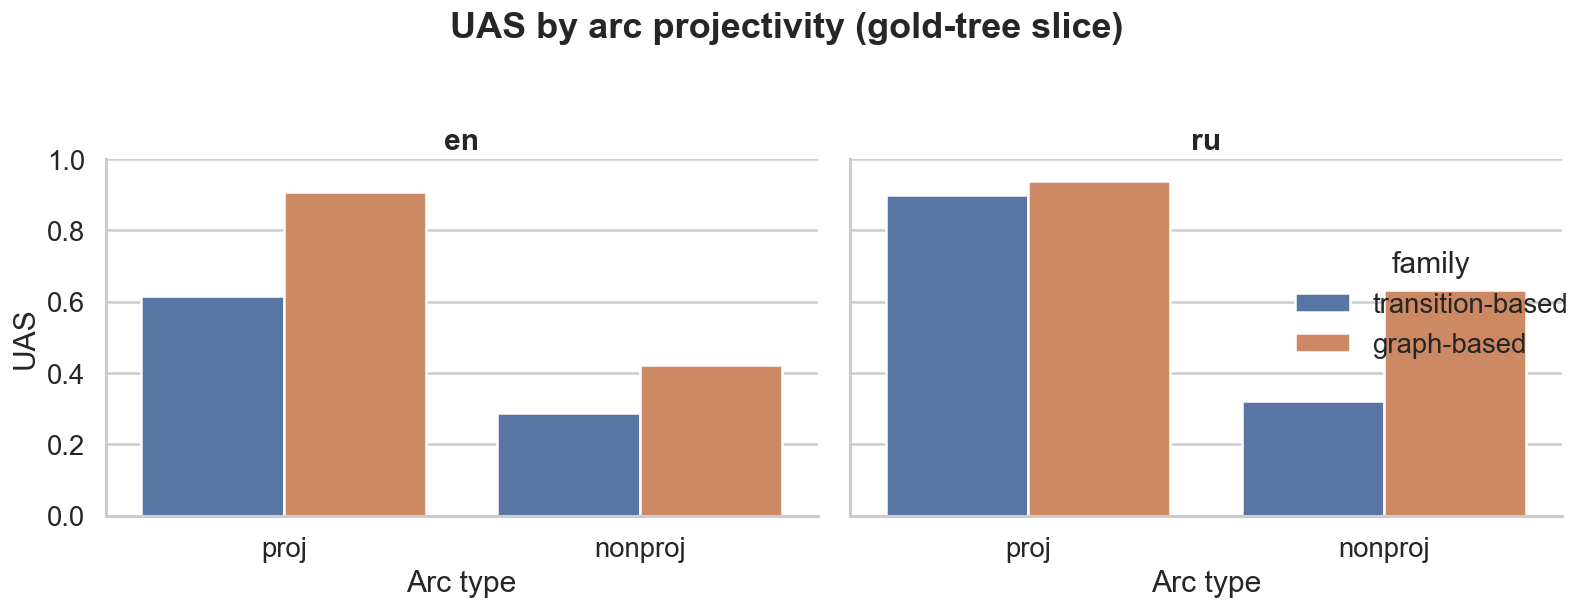

Saved fig_projectivity.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.plotting import apply_poster_style, FAMILY

apply_poster_style()
POSTER = Path("../poster")

df_proj["family"] = df_proj["parser"].map(FAMILY)
g = sns.catplot(
    df_proj, x="slice", y="uas", hue="family", col="lang",
    kind="bar", order=["proj", "nonproj"], height=5, aspect=1.1,
)
g.set_titles("{col_name}")
g.set_axis_labels("Arc type", "UAS")
g.figure.suptitle("UAS by arc projectivity (gold-tree slice)",
                  fontweight="bold", y=1.03)
for ax in g.axes.flat:
    ax.set_ylim(0.0, 1.0)
g.figure.tight_layout()
g.figure.savefig(POSTER / "fig_projectivity.png")
plt.show()
print("Saved fig_projectivity.png")

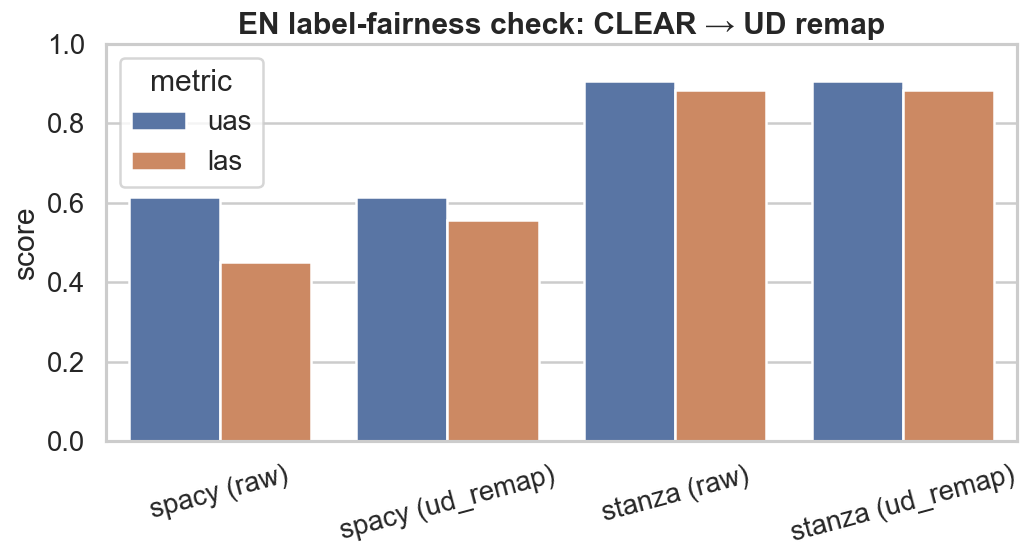

Saved fig_label_fairness.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
df_fair_plot = df_fair.copy()
df_fair_plot["label"] = df_fair_plot["parser"].str.split(":").str[0] + " (" + df_fair_plot["variant"] + ")"
order = ["spacy (raw)", "spacy (ud_remap)", "stanza (raw)", "stanza (ud_remap)"]
df_melt = df_fair_plot.melt(id_vars=["label"], value_vars=["uas", "las"],
                             var_name="metric", value_name="score")
sns.barplot(df_melt, x="label", y="score", hue="metric", order=order, ax=ax)
ax.set_ylim(0.0, 1.0)
ax.set_title("EN label-fairness check: CLEAR → UD remap", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("score")
plt.xticks(rotation=15)
fig.tight_layout()
fig.savefig(POSTER / "fig_label_fairness.png")
plt.show()
print("Saved fig_label_fairness.png")

## What we learned

- **Non-projectivity:** the graph–transition gap widens sharply on non-projective arcs (expected — global MST decoding avoids greedy traps). On RU SynTagRus this is the cleanest structural signal in the whole study.
- **EN label fairness:** remapping CLEAR→UD closes a large chunk of the spaCy EN LAS gap. The residual gap is attributable to attachment (UAS is unchanged by label remapping) and to unresolved head-structure differences around the preposition chain.
